# Day and Night Image Classifier
---

The day/night image dataset consists of 200 RGB color images in two categories: day and night. There are equal numbers of each example: 100 day images and 100 night images.

We'd like to build a classifier that can accurately label these images as day or night, and that relies on finding distinguishing features between the two types of images!

*Note: All images come from the [AMOS dataset](http://cs.uky.edu/~jacobs/datasets/amos/) (Archive of Many Outdoor Scenes).*


### Import resources

Before you get started on the project code, import the libraries and resources that you'll need.

In [11]:
import random

import cv2 # computer vision library
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

import helpers


%matplotlib inline

## Training and Testing Data
The 200 day/night images are separated into training and testing datasets. 

* 60% of these images are training images, for you to use as you create a classifier.
* 40% are test images, which will be used to test the accuracy of your classifier.

First, we set some variables to keep track of some where our images are stored:

    image_dir_training: the directory where our training image data is stored
    image_dir_test: the directory where our test image data is stored

In [2]:
IMG = '../../../img'

In [3]:
# Image data directories
image_dir_training = f'{IMG}/day_night/train'
image_dir_test = f'{IMG}/day_night/test'

## Load the datasets

These first few lines of code will load the training day/night images and store all of them in a variable, `IMAGE_LIST`. This list contains the images and their associated label ("day" or "night"). 

For example, the first image-label pair in `IMAGE_LIST` can be accessed by index: 
``` IMAGE_LIST[0][:]```.


In [5]:
# Using the load_dataset function in helpers.py
# Load training data
IMAGE_LIST = helpers.load_dataset(image_dir_training)
len(IMAGE_LIST)

32

## Construct a `STANDARDIZED_LIST` of input images and output labels.

This function takes in a list of image-label pairs and outputs a **standardized** list of resized images and numerical labels.

In [6]:
# Standardize all training images
STANDARDIZED_LIST = helpers.standardize(IMAGE_LIST)

## Visualize the standardized data

Display a standardized image from STANDARDIZED_LIST.

Shape: (600, 1100, 3)
Label: day


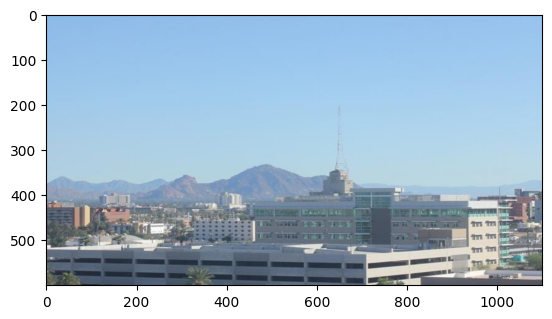

In [7]:
# Display a standardized image and its label

# Select an image by index
image_num = 0
selected_image = STANDARDIZED_LIST[image_num][0]
selected_label = STANDARDIZED_LIST[image_num][1]

# Display image and data about it
plt.imshow(selected_image)
print(f'Shape: {selected_image.shape}')
print(f'Label: {"day" if selected_label == 1 else "night"}')

# Feature Extraction

Create a feature that represents the brightness in an image. We'll be extracting the **average brightness** using HSV colorspace. Specifically, we'll use the V channel (a measure of brightness), add up the pixel values in the V channel, then divide that sum by the area of the image to get the average Value of the image.


---
###  Find the average brightness using the V channel

This function takes in a **standardized** RGB image and returns a feature (a single value) that represent the average level of brightness in the image. We'll use this value to classify the image as day or night.

In [8]:
def avg_brightness(rgb_image):
    hsv = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2HSV)
    sum_brightness = np.sum(hsv[:,:,2])
    H = 600
    W = 1100
    AREA = H * W
    avg = sum_brightness / AREA
    return avg

Avg brightness: 27.820572727272726


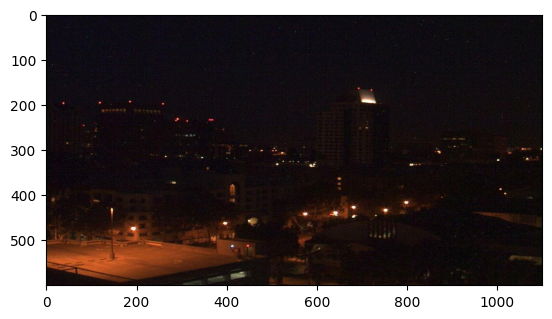

In [9]:
image_num = -3
test_im = STANDARDIZED_LIST[image_num][0]
avg = avg_brightness(test_im)
print(f'Avg brightness: {avg}')
plt.imshow(test_im);

# Classification and Visualizing Error

In this section, we'll turn our average brightness feature into a classifier that takes in a standardized image and returns a `predicted_label` for that image. This `estimate_label` function should return a value: 0 or 1 (night or day, respectively).

---
### TODO: Build a complete classifier 

Complete this code so that it returns an estimated class label given an input RGB image.

In [10]:
def estimate_label(rgb_image):
    avg = avg_brightness(rgb_image)
    THRESH = 103  # optimal in the FULL training set
    predicted_label = 1 if avg >= THRESH else 0
    return predicted_label

## Testing the classifier

Here is where we test your classification algorithm using our test set of data that we set aside at the beginning of the notebook!

Since we are using a pretty simple brightess feature, we may not expect this classifier to be 100% accurate. We'll aim for around 75-85% accuracy usin this one feature.


### Test dataset

Below, we load in the test dataset, standardize it using the `standardize` function you defined above, and then **shuffle** it; this ensures that order will not play a role in testing accuracy.


In [12]:
TEST_IMAGE_LIST = helpers.load_dataset(image_dir_test)
STANDARDIZED_TEST_LIST = helpers.standardize(TEST_IMAGE_LIST)
random.shuffle(STANDARDIZED_TEST_LIST)

## Determine the Accuracy

Compare the output of your classification algorithm (a.k.a. your "model") with the true labels and determine the accuracy.

This code stores all the misclassified images, their predicted labels, and their true labels, in a list called `misclassified`.

In [13]:
def get_misclassified_images(test_images):
    misclassified_images_labels = []
    for image in test_images:
        im, true_label = image
        predicted_label = estimate_label(im)
        if predicted_label != true_label:
            misclassified_images_labels.append(
                (im, predicted_label, true_label))
    return misclassified_images_labels

In [14]:
MISCLASSIFIED = get_misclassified_images(STANDARDIZED_TEST_LIST)
total = len(STANDARDIZED_TEST_LIST)
n_correct = total - len(MISCLASSIFIED)
accuracy = n_correct / total
print(f'Accuracy: {accuracy}')
print(f'Number of misclassified images: {len(MISCLASSIFIED)}/{total}')

Accuracy: 1.0
Number of misclassified images: 0/43


---
<a id='task9'></a>
### TO-DO: Visualize the misclassified images

Visualize some of the images you classified wrong (in the `MISCLASSIFIED` list) and note any qualities that make them difficult to classify. This will help you identify any weaknesses in your classification algorithm.

In [17]:
n = 0
if len(MISCLASSIFIED) > n:
    a, pred, label = MISCLASSIFIED[n]
    plt.imshow(a)
    print(f'Predicted: {pred}, actually {label}')
else:
    print('No misclassified images')

No misclassified images


---
<a id='question2'></a>
## (Question): After visualizing these misclassifications, what weaknesses do you think your classification algorithm has?

**Answer:** Write your answer, here.

# 5. Improve your algorithm!

* (Optional) Tweak your threshold so that accuracy is better.
* (Optional) Add another feature that tackles a weakness you identified!
---
